# Проект Обучение с учителем, для интернет-магазина «В один клик»

**Вступление**

Интернет-магазин «В один клик» столкнулся со снижением активности постоянных клиентов. Цель данного проекта - разработать решение на основе машинного обучения для удержания клиентов и повышения их покупательской активности.

Мы построим модель классификации, которая будет прогнозировать вероятность снижения активности клиента в ближайшие три месяца. На основе прогнозов модели и данных о прибыльности клиентов мы проведем сегментацию покупателей. Это позволит разработать персонализированные предложения для удержания наиболее ценных клиентов, находящихся в группе риска.

**План работы:**

1. Загрузка и предобработка данных: Изучим и подготовим данные из нескольких источников, содержащие информацию о поведении клиентов на сайте, их покупательской активности и финансовых показателях.

2. Исследовательский и корреляционный анализ: Проанализируем данные, чтобы выявить ключевые факторы, влияющие на активность покупателей, и проверим признаки на мультиколлинеарность.

3. Построение и выбор модели: Создадим и сравним несколько моделей классификации (KNeighborsClassifier, DecisionTreeClassifier, LogisticRegression, SVC) с использованием пайплайнов. Подберем оптимальные гиперпараметры и выберем лучшую модель на основе подходящей метрики качества.

4. Анализ важности признаков: Оценим влияние различных характеристик клиента на итоговый прогноз с помощью метода SHAP, чтобы понять основные причины снижения активности.

5. Сегментация и разработка рекомендаций: Используя прогнозы модели и финансовые данные, выделим ключевые сегменты клиентов. Для одного из сегментов разработаем конкретные бизнес-предложения, направленные на повышение их лояльности и покупательской активности.

Импорт библиотек и установка стиля.

In [1]:
!pip install shap -q
!pip install phik -q
!pip install -U scikit-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import phik
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)

# Шаг 1. Загрузка данных

In [3]:
try:
    # Загрузка данных с учетом особенностей (разделители, десятичные запятые)
    market_file = pd.read_csv('/datasets/market_file.csv', sep=',', decimal='.')
    market_money = pd.read_csv('/datasets/market_money.csv', sep=',', decimal='.')
    market_time = pd.read_csv('/datasets/market_time.csv', sep=',', decimal='.')
    # В файле money.csv разделитель - точка с запятой, а десятичный - запятая
    money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')

    print("market_file.csv:")
    display(market_file.head())
    market_file.info()

    print("\nmarket_money.csv:")
    display(market_money.head())
    market_money.info()

    print("\nmarket_time.csv:")
    display(market_time.head())
    market_time.info()

    print("\nmoney.csv:")
    display(money.head())
    money.info()

    print("\n Данные успешно загружены и проверены.")

except FileNotFoundError as e:
    print(f"Ошибка: Файл не найден. Убедитесь, что файлы находятся в правильной директории. {e}")
    
files = [market_file, market_money, market_time, money]

market_file.csv:


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB

market_time.csv:


,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB

money.csv:


,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB

 Данные успешно загружены и проверены.


**Промежуточный вывод**

* Присутствуют опечатки в тип_серсива

* Присутствуют опечатки в период

# Шаг 2. Предобработка данных

Проверим пропуски в каждой из таблиц.

In [4]:
for file in files: 
    display(file.isnull().sum())

id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

id         0
Период     0
Выручка    0
dtype: int64

id        0
Период    0
минут     0
dtype: int64

id         0
Прибыль    0
dtype: int64

Пропуски отсутствуют. Посмотрим describe, что-бы проверить есть ли отрицательные значения или другие аномалии.

In [5]:
for file in files: 
    display(file.describe())

,id,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,215997.500000,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,375.421985,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,215348.000000,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,215672.750000,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,215997.500000,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,216322.250000,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


,id,Выручка
count,3900.000000,3900.000000
mean,215997.500000,5025.696051
std,375.325686,1777.704104
min,215348.000000,0.000000
25%,215672.750000,4590.150000
50%,215997.500000,4957.500000
75%,216322.250000,5363.000000
max,216647.000000,106862.200000


,id,минут
count,2600.000000,2600.000000
mean,215997.500000,13.336154
std,375.349754,4.080198
min,215348.000000,4.000000
25%,215672.750000,10.000000
50%,215997.500000,13.000000
75%,216322.250000,16.000000
max,216647.000000,23.000000


,id,Прибыль
count,1300.000000,1300.000000
mean,215997.500000,3.996631
std,375.421985,1.013722
min,215348.000000,0.860000
25%,215672.750000,3.300000
50%,215997.500000,4.045000
75%,216322.250000,4.670000
max,216647.000000,7.430000


Не уверен что значение 0 в прибыли аномалия, возможно заказ отменён?
Исправим опечатки.

In [6]:
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace('стандартт', 'стандарт')
print("\nУникальные значения в 'Тип сервиса' после исправления:", market_file['Тип сервиса'].unique())
market_time['Период'] = market_time['Период'].replace('предыдцщий_месяц', 'предыдущий_месяц')
print("\nУникальные значения в 'Период' (market_time) после исправления:", market_time['Период'].unique())


Уникальные значения в 'Тип сервиса' после исправления: ['премиум' 'стандарт']

Уникальные значения в 'Период' (market_time) после исправления: ['текущий_месяц' 'предыдущий_месяц']


**Вывод**

* Предобработка завершена, данные пригодны для исследовательского анализа.

* Исправлены опечатки.

* Пропуски отсутствуют.

# Шаг 3. Исследовательский анализ данных

Отбор клиентов с активностью не менее 3 месяцев

In [7]:
# Клиент считается активным в месяце, если его выручка > 0
active_clients_per_month = market_money[market_money['Выручка'] > 0]
# Считаем количество активных месяцев для каждого клиента
client_activity_counts = active_clients_per_month.groupby('id')['Период'].nunique()
# Отбираем id клиентов, которые были активны во всех трех периодах
active_3_months_ids = client_activity_counts[client_activity_counts == 3].index

In [8]:
print(f"\n--- Результаты отбора ---")
print(f"Всего клиентов: {market_file['id'].nunique()}")
print(f"Найдено клиентов, активных все 3 месяца: {len(active_3_months_ids)}")


--- Результаты отбора ---
Всего клиентов: 1300
Найдено клиентов, активных все 3 месяца: 1297


Исследовательский анализ данных для отобранной группы

In [9]:
market_file_active = market_file[market_file['id'].isin(active_3_months_ids)]
market_money_active = market_money[market_money['id'].isin(active_3_months_ids)]
market_time_active = market_time[market_time['id'].isin(active_3_months_ids)]
money_active = money[money['id'].isin(active_3_months_ids)]

Создадим функцию для анализа категориальных признаков:

In [10]:
def analyze_categorical(df, column_name):
    print(f"Анализ категориального признака: '{column_name}'")
    print("--------------------------------------------------")
    print("Количество уникальных значений:")
    # Выводим количество по каждой категории
    print(df[column_name].value_counts())
    print("\nДоля каждой категории:")
    # Выводим долю каждой категории
    print(df[column_name].value_counts(normalize=True))
    print("\n")

    plt.figure(figsize=(12, 7))
    # Для признаков с большим количеством категорий лучше подходит горизонтальная диаграмма
    if df[column_name].nunique() > 5:
        sns.countplot(y=column_name, data=df, order=df[column_name].value_counts().index)
    else:
        sns.countplot(x=column_name, data=df, order=df[column_name].value_counts().index)
        
    plt.title(f"Распределение признака '{column_name}'")
    plt.xlabel("Количество")
    plt.ylabel("Значение")
    plt.tight_layout()
    plt.show()
    print("\n" + "="*60 + "\n")

Теперь фукнция для дискоретных:

In [11]:
def analyze_discrete_numeric(df, column_name):
    print(f"Анализ дискретного численного признака: '{column_name}'")
    print("--------------------------------------------------")
    print("Описательная статистика:")
    print(df[column_name].describe())
    print("\nКоличество уникальных значений:")
    print(df[column_name].value_counts().sort_index())
    print("\n")

    plt.figure(figsize=(12, 7))
    sns.countplot(x=column_name, data=df, color='skyblue')
    plt.title(f"Распределение признака '{column_name}'")
    plt.xlabel("Значение")
    plt.ylabel("Количество")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\n" + "="*60 + "\n")

Фукнция для непрерывных численных признаков:

In [12]:
def analyze_continuous_numeric(df, column_name):
    print(f"Анализ непрерывного численного признака: '{column_name}'")
    print("--------------------------------------------------")
    print("Описательная статистика:")
    print(df[column_name].describe())
    print("\n")

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Гистограмма для оценки распределения
    sns.histplot(df[column_name], kde=True, ax=axes[0])
    axes[0].set_title(f"Гистограмма распределения '{column_name}'")
    axes[0].set_xlabel("Значение")
    axes[0].set_ylabel("Частота")

    # Ящик с усами (Boxplot) для выявления аномалий
    sns.boxplot(x=df[column_name], ax=axes[1])
    axes[1].set_title(f"Ящик с усами для '{column_name}' (поиск аномалий)")
    axes[1].set_xlabel("Значение")

    plt.suptitle(f"Анализ распределения и аномалий признака '{column_name}'", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    print("\n" + "="*60 + "\n")

И функция для анализа по всем таблицам:

In [13]:
def run_eda(market_file_active, market_money_active, market_time_active, money_active):
    
    # Анализ DataFrame `market_file_active` ---
    print("="*20 + " Анализ DataFrame: market_file_active " + "="*20)
    
    # Разделяем признаки на категориальные и численные
    categorical_cols_mfa = market_file_active.select_dtypes(include=['object']).columns
    numeric_cols_mfa = market_file_active.select_dtypes(include=['int64', 'float64']).columns.drop('id')

    print("\n--- Анализ категориальных признаков ---\n")
    for col in categorical_cols_mfa:
        analyze_categorical(market_file_active, col)

    print("\n--- Анализ численных признаков ---\n")
    for col in numeric_cols_mfa:
        # Определяем дискретность признака по количеству уникальных значений (<=20)
        is_discrete = market_file_active[col].nunique() <= 20
        
        if is_discrete:
            analyze_discrete_numeric(market_file_active, col)
        else:
            analyze_continuous_numeric(market_file_active, col)


    # Анализ DataFrame `market_money_active` ---
    print("="*20 + " Анализ DataFrame: market_money_active " + "="*20)
    
    analyze_categorical(market_money_active, 'Период')
    analyze_continuous_numeric(market_money_active, 'Выручка')

    # Дополнительный анализ: выручка по периодам
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Период', y='Выручка', data=market_money_active)
    plt.title('Распределение выручки по периодам')
    plt.xlabel('Период')
    plt.ylabel('Выручка')
    plt.tight_layout()
    plt.show()


    # Анализ DataFrame `market_time_active` ---
    print("="*20 + " Анализ DataFrame: market_time_active " + "="*20)

    analyze_categorical(market_time_active, 'Период')

    # Проверяем, является ли признак 'минут' дискретным
    if market_time_active['минут'].nunique() <= 20:
        analyze_discrete_numeric(market_time_active, 'минут')
    else:
        analyze_continuous_numeric(market_time_active, 'минут')

    # Дополнительный анализ: время по периодам
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='Период', y='минут', data=market_time_active)
    plt.title('Распределение времени (минут) по периодам')
    plt.xlabel('Период')
    plt.ylabel('Минут')
    plt.tight_layout()
    plt.show()


    # Анализ DataFrame `money_active` ---
    print("="*20 + " Анализ DataFrame: money_active " + "="*20)

    analyze_continuous_numeric(money_active, 'Прибыль')

    print("\nИсследовательский анализ данных завершен.")

==================== Анализ DataFrame: market_file_active ====================

--- Анализ категориальных признаков ---

Анализ категориального признака: 'Покупательская активность'
--------------------------------------------------
Количество уникальных значений:
Прежний уровень    802
Снизилась          495
Name: Покупательская активность, dtype: int64

Доля каждой категории:
Прежний уровень    0.61835
Снизилась          0.38165
Name: Покупательская активность, dtype: float64




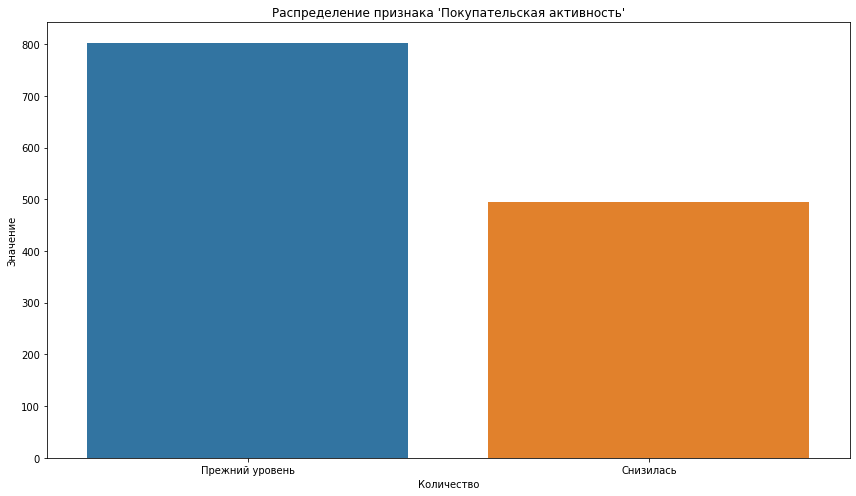



Анализ категориального признака: 'Тип сервиса'
--------------------------------------------------
Количество уникальных значений:
стандарт    922
премиум     375
Name: Тип сервиса, dtype: int64

Доля каждой категории:
стандарт    0.710871
премиум     0.289129
Name: Тип сервиса, dtype: float64




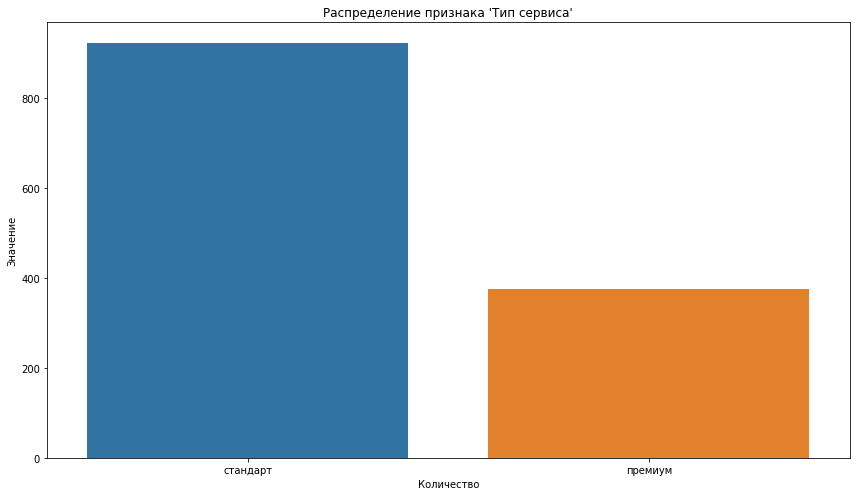



Анализ категориального признака: 'Разрешить сообщать'
--------------------------------------------------
Количество уникальных значений:
да     959
нет    338
Name: Разрешить сообщать, dtype: int64

Доля каждой категории:
да     0.739399
нет    0.260601
Name: Разрешить сообщать, dtype: float64




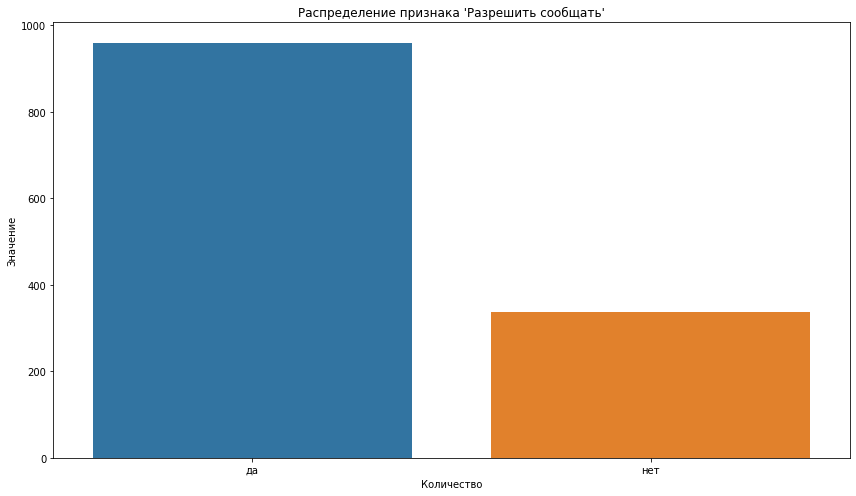



Анализ категориального признака: 'Популярная_категория'
--------------------------------------------------
Количество уникальных значений:
Товары для детей                        329
Домашний текстиль                       250
Косметика и аксесуары                   223
Техника для красоты и здоровья          183
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: Популярная_категория, dtype: int64

Доля каждой категории:
Товары для детей                        0.253662
Домашний текстиль                       0.192753
Косметика и аксесуары                   0.171935
Техника для красоты и здоровья          0.141095
Мелкая бытовая техника и электроника    0.134156
Кухонная посуда                         0.106399
Name: Популярная_категория, dtype: float64




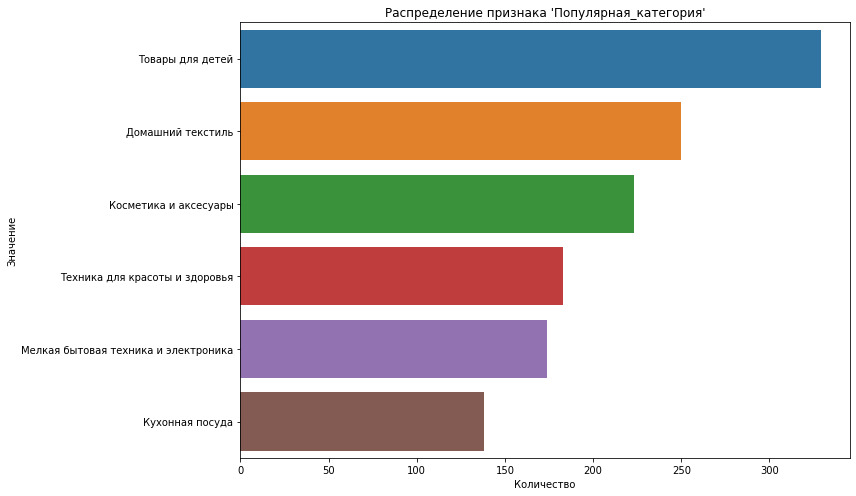




--- Анализ численных признаков ---

Анализ непрерывного численного признака: 'Маркет_актив_6_мес'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        4.254433
std         1.015618
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: Маркет_актив_6_мес, dtype: float64




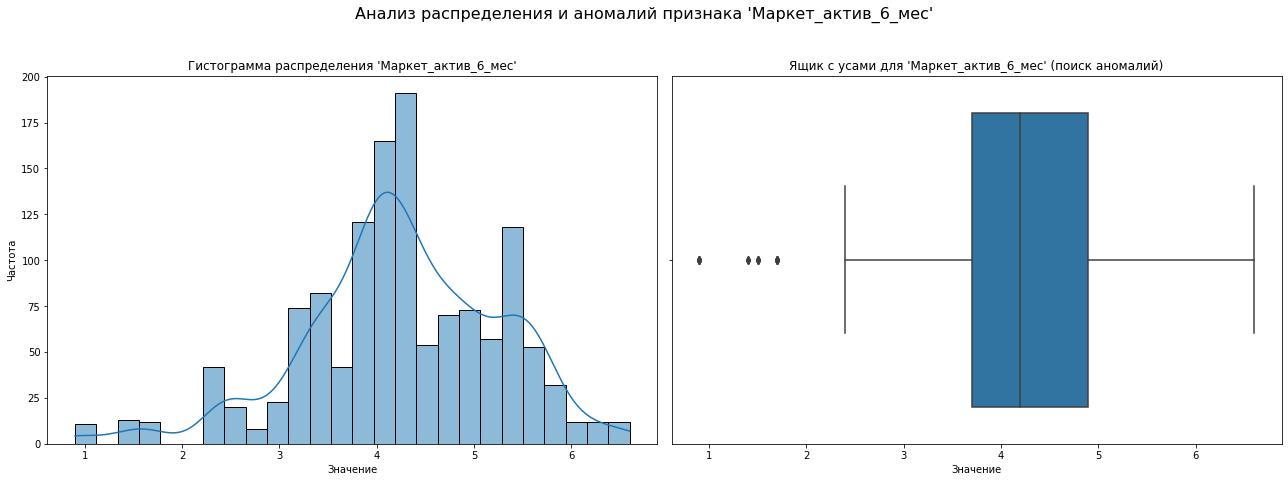



Анализ дискретного численного признака: 'Маркет_актив_тек_мес'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        4.009252
std         0.696048
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: Маркет_актив_тек_мес, dtype: float64

Количество уникальных значений:
3    308
4    669
5    320
Name: Маркет_актив_тек_мес, dtype: int64




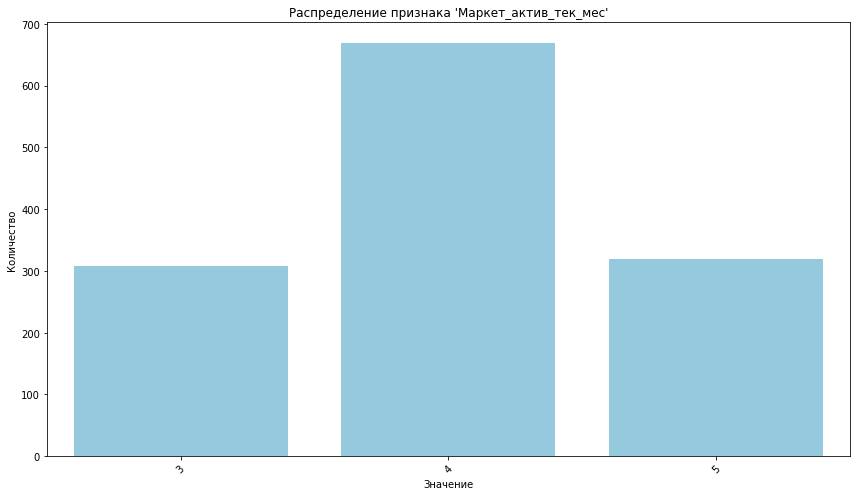



Анализ непрерывного численного признака: 'Длительность'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean      602.993832
std       249.101456
min       121.000000
25%       410.000000
50%       607.000000
75%       806.000000
max      1079.000000
Name: Длительность, dtype: float64




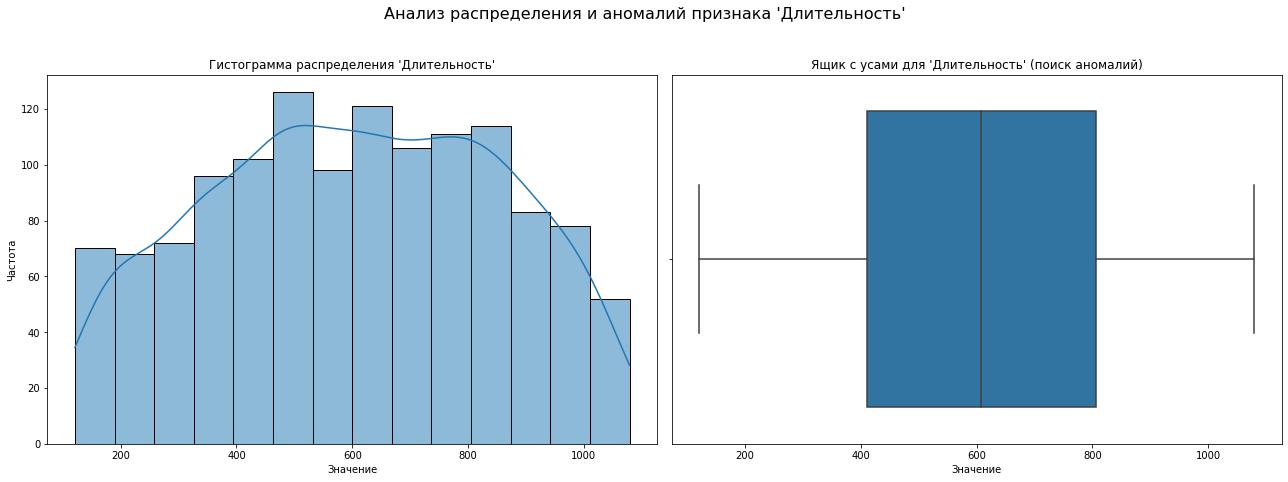



Анализ непрерывного численного признака: 'Акционные_покупки'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        0.320547
std         0.249657
min         0.110000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: Акционные_покупки, dtype: float64




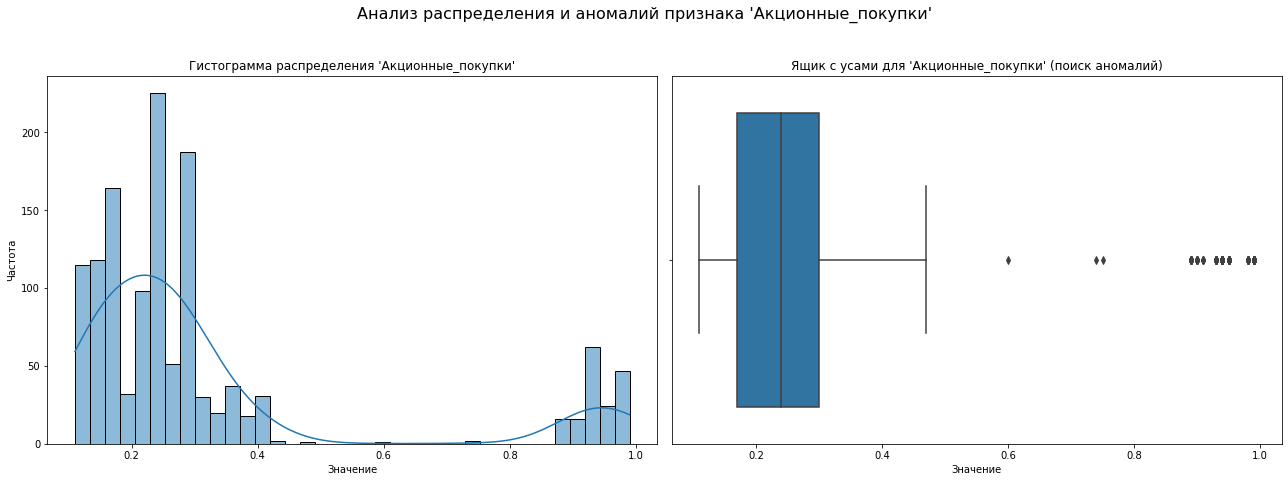



Анализ дискретного численного признака: 'Средний_просмотр_категорий_за_визит'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        3.267540
std         1.354623
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: Средний_просмотр_категорий_за_визит, dtype: float64

Количество уникальных значений:
1    106
2    312
3    355
4    262
5    177
6     85
Name: Средний_просмотр_категорий_за_визит, dtype: int64




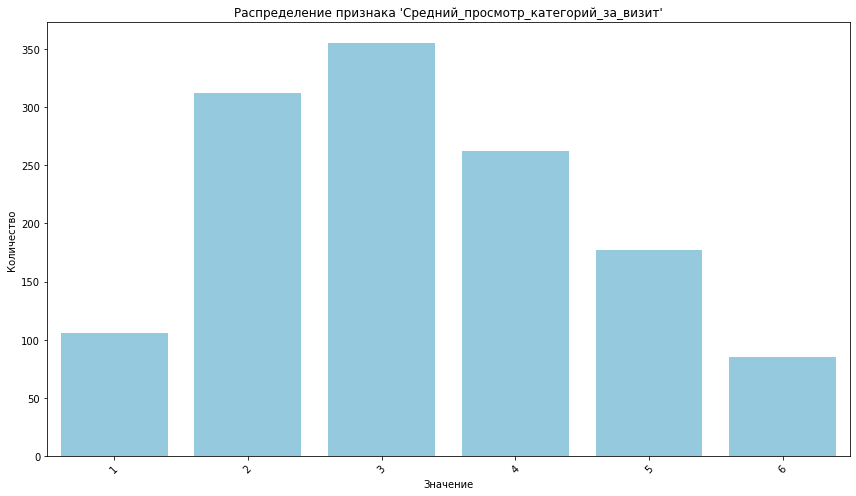



Анализ дискретного численного признака: 'Неоплаченные_продукты_штук_квартал'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        2.841172
std         1.973451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: Неоплаченные_продукты_штук_квартал, dtype: float64

Количество уникальных значений:
0     116
1     261
2     259
3     217
4     197
5     135
6      44
7      34
8      20
9      10
10      4
Name: Неоплаченные_продукты_штук_квартал, dtype: int64




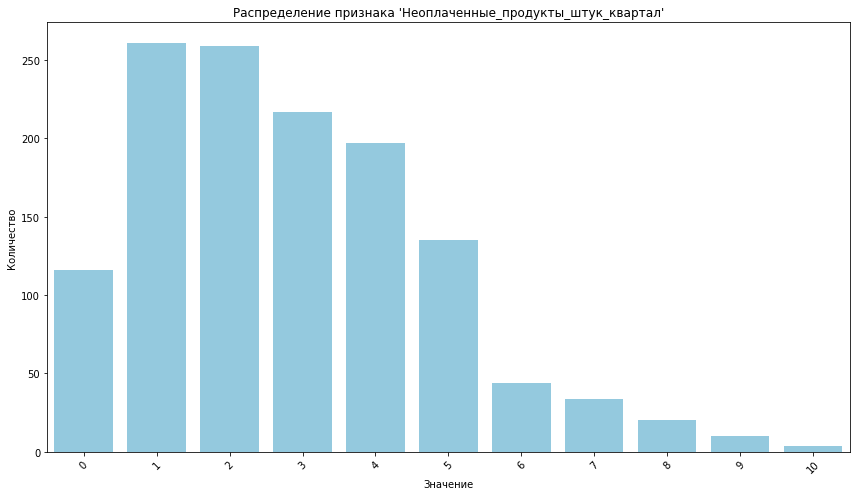



Анализ дискретного численного признака: 'Ошибка_сервиса'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        4.184271
std         1.950973
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: Ошибка_сервиса, dtype: float64

Количество уникальных значений:
0     17
1     73
2    189
3    226
4    256
5    208
6    156
7     92
8     66
9     14
Name: Ошибка_сервиса, dtype: int64




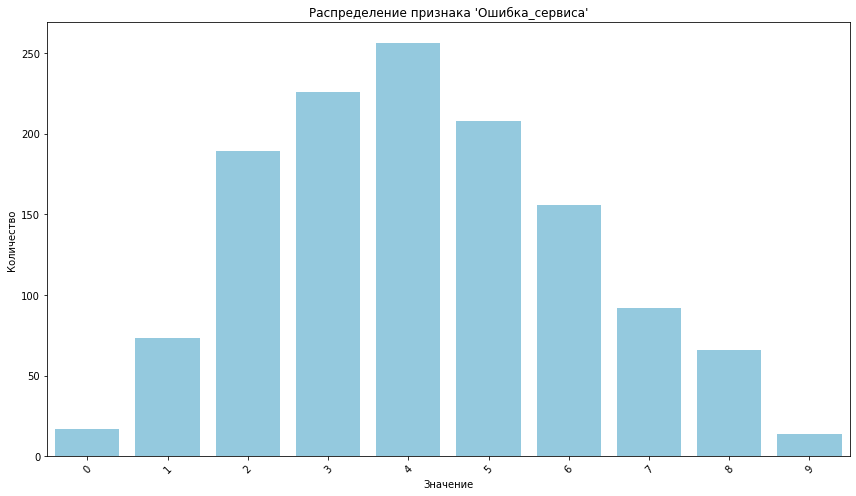



Анализ дискретного численного признака: 'Страниц_за_визит'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        8.186584
std         3.977061
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: Страниц_за_визит, dtype: float64

Количество уникальных значений:
1      20
2      57
3      76
4     112
5     113
6     127
7     102
8     109
9     108
10    104
11     92
12     73
13     61
14     53
15     36
16     21
17     19
18      7
19      5
20      2
Name: Страниц_за_визит, dtype: int64




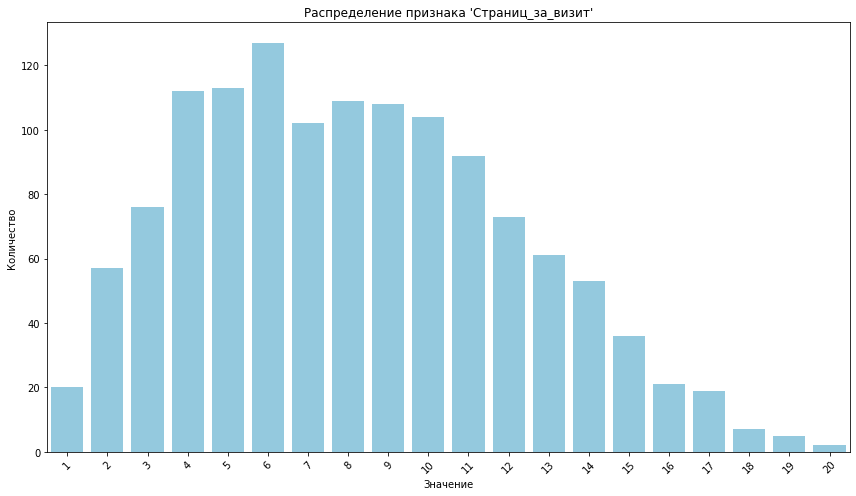



==================== Анализ DataFrame: market_money_active ====================
Анализ категориального признака: 'Период'
--------------------------------------------------
Количество уникальных значений:
текущий_месяц          1297
предыдущий_месяц       1297
препредыдущий_месяц    1297
Name: Период, dtype: int64

Доля каждой категории:
текущий_месяц          0.333333
предыдущий_месяц       0.333333
препредыдущий_месяц    0.333333
Name: Период, dtype: float64




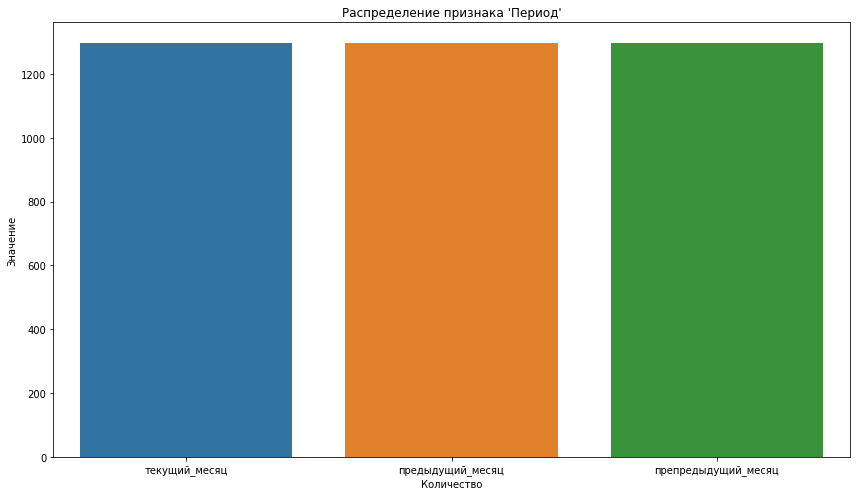



Анализ непрерывного численного признака: 'Выручка'
--------------------------------------------------
Описательная статистика:
count      3891.000000
mean       5033.718890
std        1768.471286
min        2758.700000
25%        4592.000000
50%        4959.000000
75%        5363.200000
max      106862.200000
Name: Выручка, dtype: float64




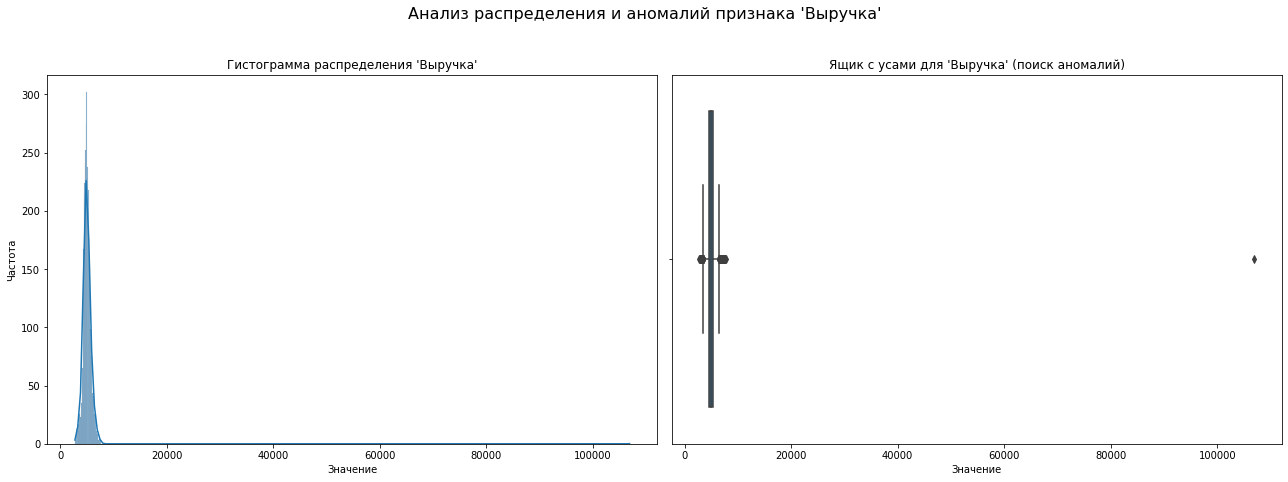

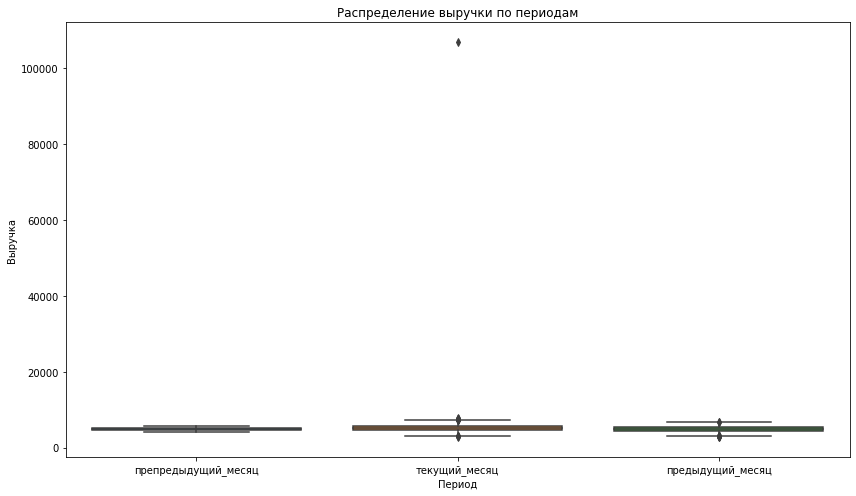

==================== Анализ DataFrame: market_time_active ====================
Анализ категориального признака: 'Период'
--------------------------------------------------
Количество уникальных значений:
текущий_месяц       1297
предыдущий_месяц    1297
Name: Период, dtype: int64

Доля каждой категории:
текущий_месяц       0.5
предыдущий_месяц    0.5
Name: Период, dtype: float64




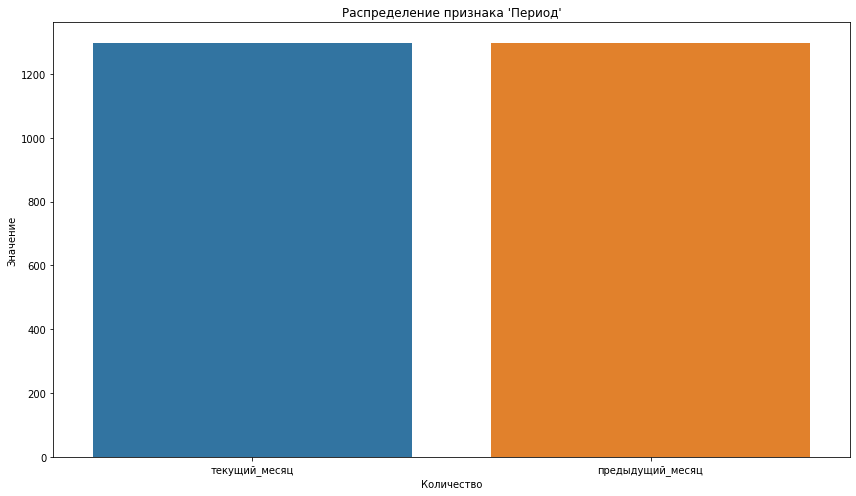



Анализ дискретного численного признака: 'минут'
--------------------------------------------------
Описательная статистика:
count    2594.000000
mean       13.340401
std         4.081999
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

Количество уникальных значений:
4       9
5      22
6      58
7      88
8     141
9     186
10    204
11    220
12    236
13    204
14    255
15    174
16    162
17    163
18    145
19    119
20    101
21     53
22     40
23     14
Name: минут, dtype: int64




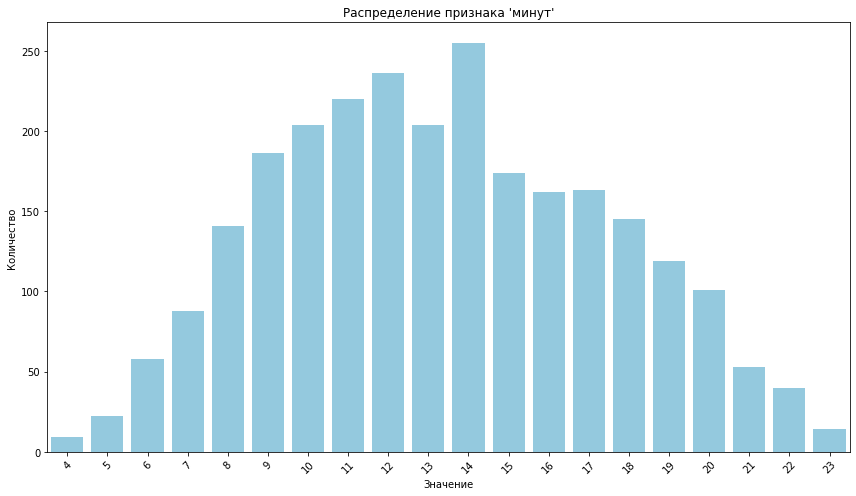

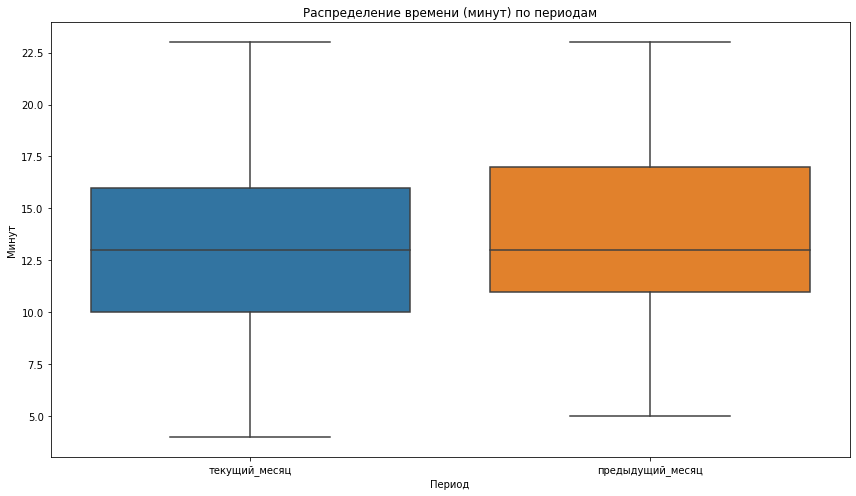

==================== Анализ DataFrame: money_active ====================
Анализ непрерывного численного признака: 'Прибыль'
--------------------------------------------------
Описательная статистика:
count    1297.000000
mean        3.997610
std         1.010813
min         0.860000
25%         3.300000
50%         4.040000
75%         4.670000
max         7.430000
Name: Прибыль, dtype: float64




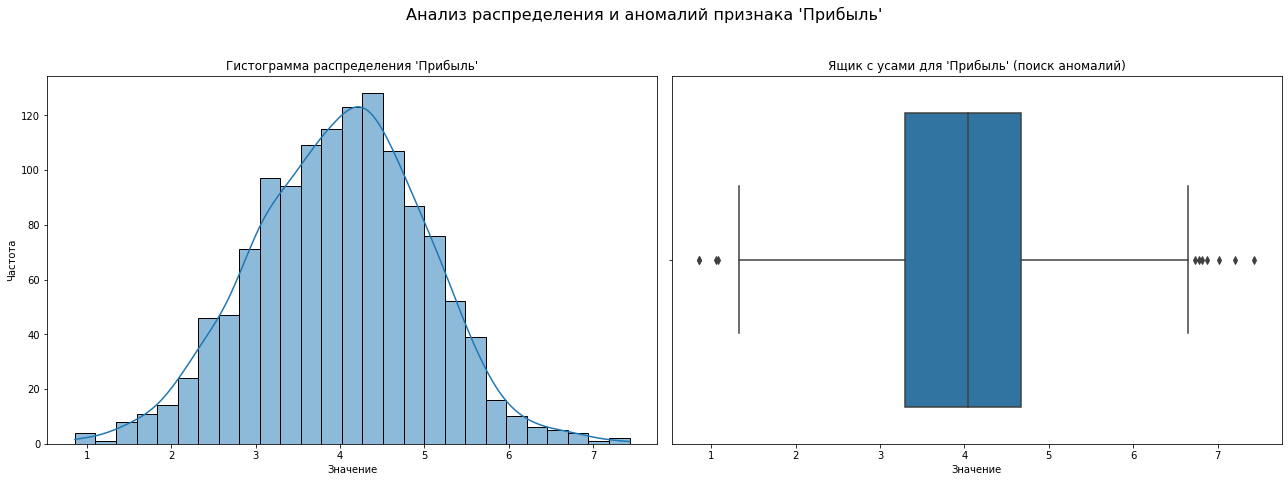




Исследовательский анализ данных завершен.


In [14]:
run_eda(market_file_active, market_money_active, market_time_active, money_active)

**Вывод:**

* Анализ market_file_active (Основные данные о клиентах)

Категориальные признаки: 

1. Покупательская активность (Целевой признак): Наблюдается умеренный дисбаланс классов. 62% клиентов сохранили активность на прежнем уровне, в то время как у 38% она снизилась.

2. Тип сервиса: Большинство клиентов (71%) пользуются стандартным тарифом.

3. Разрешить сообщать: Подавляющее большинство клиентов (74%) дали согласие на получение уведомлений.

4. Популярная категория: Наиболее востребованной категорией являются "Товары для детей" (25%), за ней следует "Домашний текстиль" (19%).

Численные признаки:

1. Непрерывные признаки (Маркет_актив_6_мес, Длительность, Акционные_покупки): Эти переменные имеют распределения, близкие к нормальному, без явных выбросов. Их значения находятся в логичных и ожидаемых диапазонах.

2. Дискретные признаки (Маркет_актив_тек_мес, Средний_просмотр_категорий_за_визит и др.): Все дискретные признаки демонстрируют правдоподобные распределения. Например, количество ошибок сервиса и неоплаченных товаров у большинства пользователей невелико, что соответствует норме.

* Анализ market_money_active (Данные о выручке)

1. Распределение: Данные крайне асимметричны. Основная масса значений (более 95%) сосредоточена в узком диапазоне, но при этом существуют единичные, но экстремально высокие значения. Наличие таких выбросов сильно искажает среднее значение и может негативно сказаться на качестве и стабильности будущих моделей, в тоже время, это может быть результат закупки оптовых клиентов.

* Анализ market_time_active (Данные о времени на сайте)

1. Период: Данные сбалансированы и содержат равное количество записей для текущего и предыдущего месяцев.

2. минут: Время, проведенное на сайте, имеет нормальное распределение с пиком около 13-14 минут. Аномальных значений не выявлено.

* Анализ money_active (Данные о прибыли)

1. Прибыль: Этот признак имеет симметричное, близкое к нормальному распределение. Среднее значение и медиана практически совпадают, что указывает на отсутствие значительных выбросов.

**Итоговый вывод**

1. Качество данных: Данные полные, без пропусков, типы данных корректны.

2. Типичные клиент пользуется стандартным тарифом, согласен на получение уведомлений, и чаще всего покупает товары для детей .

3. Перед дальнешей работой стоит принять решение по аномальным значениям в выручке.

**Удаление аномалий.**

In [15]:
ids_to_remove = market_money_active[market_money_active['Выручка'] > 8000]['id'].unique()

print(f"Найдено {len(ids_to_remove)} уникальных ID для удаления на основе фильтра по выручке.")

list_of_dfs = {
    "market_file_active": market_file_active,
    "market_money_active": market_money_active,
    "market_time_active": market_time_active,
    "money_active": money_active
}

for name, df in list_of_dfs.items():
    print(f"\n--- Обработка таблицы: {name} ---")
    if 'id' in df.columns:
        rows_before = df.shape[0]
        print(f"Строк до удаления: {rows_before}")
        df_cleaned = df[~df['id'].isin(ids_to_remove)].copy()
        rows_after = df_cleaned.shape[0]
        print(f"Строк после удаления: {rows_after}")
        print(f"Удалено строк: {rows_before - rows_after}")
        list_of_dfs[name] = df_cleaned

    else:
        print(f"В таблице {name} нет колонки 'id'. Пропускаем.")

market_file_active = list_of_dfs["market_file_active"]
market_money_active = list_of_dfs["market_money_active"]
market_time_active = list_of_dfs["market_time_active"]
money_active = list_of_dfs["money_active"]

print("\n--- Все таблицы были успешно очищены по условию 'Выручка' > 8000. ---")

Найдено 1 уникальных ID для удаления на основе фильтра по выручке.

--- Обработка таблицы: market_file_active ---
Строк до удаления: 1297
Строк после удаления: 1296
Удалено строк: 1

--- Обработка таблицы: market_money_active ---
Строк до удаления: 3891
Строк после удаления: 3888
Удалено строк: 3

--- Обработка таблицы: market_time_active ---
Строк до удаления: 2594
Строк после удаления: 2592
Удалено строк: 2

--- Обработка таблицы: money_active ---
Строк до удаления: 1297
Строк после удаления: 1296
Удалено строк: 1

--- Все таблицы были успешно очищены по условию 'Выручка' > 8000. ---


# Шаг 4. Объединение таблиц

In [16]:
# Преобразуем таблицу с выручкой
# Используем pivot_table, чтобы развернуть строки с периодами в столбцы
money_pivot = market_money_active.pivot_table(index='id', columns='Период', values='Выручка').reset_index()

# Переименовываем столбцы для удобства
money_pivot.columns = ['id', 'Выручка_препредыдущий_месяц', 'Выручка_предыдущий_месяц', 'Выручка_текущий_месяц']
# Заполняем возможные пропуски нулями (если клиент не был активен в какой-то месяц)
money_pivot = money_pivot.fillna(0)

# 2. Преобразуем таблицу со временем
time_pivot = market_time_active.pivot_table(index='id', columns='Период', values='минут').reset_index()

# Переименовываем столбцы
time_pivot.columns = ['id', 'минут_предыдущий_месяц', 'минут_текущий_месяц']
time_pivot = time_pivot.fillna(0)

In [17]:
# Преобразуем таблицу со временем
time_pivot = market_time_active.pivot_table(index='id', columns='Период', values='минут').reset_index()

# Переименовываем столбцы
time_pivot.columns = ['id', 'минут_предыдущий_месяц', 'минут_текущий_месяц']
time_pivot = time_pivot.fillna(0)

In [18]:
# Объединяем таблицы
# Сначала основную таблицу 'market_file' с данными о выручке
final_df = pd.merge(market_file_active, money_pivot, on='id', how='left')

# Затем добавляем данные о времени, проведенном на сайте
final_df = pd.merge(final_df, time_pivot, on='id', how='left')

In [19]:
print("\n--- Таблицы успешно объединены. ---")
print("Итоговая структура данных (первые 5 строк):")
display(final_df.head())

print("\nИнформация о типах данных в итоговой таблице:")
final_df.info()


--- Таблицы успешно объединены. ---
Итоговая структура данных (первые 5 строк):


,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит,Выручка_препредыдущий_месяц,Выручка_предыдущий_месяц,Выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10



Информация о типах данных в итоговой таблице:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 0 to 1295
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1296 non-null   int64  
 1   Покупательская активность            1296 non-null   object 
 2   Тип сервиса                          1296 non-null   object 
 3   Разрешить сообщать                   1296 non-null   object 
 4   Маркет_актив_6_мес                   1296 non-null   float64
 5   Маркет_актив_тек_мес                 1296 non-null   int64  
 6   Длительность                         1296 non-null   int64  
 7   Акционные_покупки                    1296 non-null   float64
 8   Популярная_категория                 1296 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1296 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1296 non-nul

**Вывод**

* Таблицы успешно объединены.

# Шаг 5. Корреляционный анализ

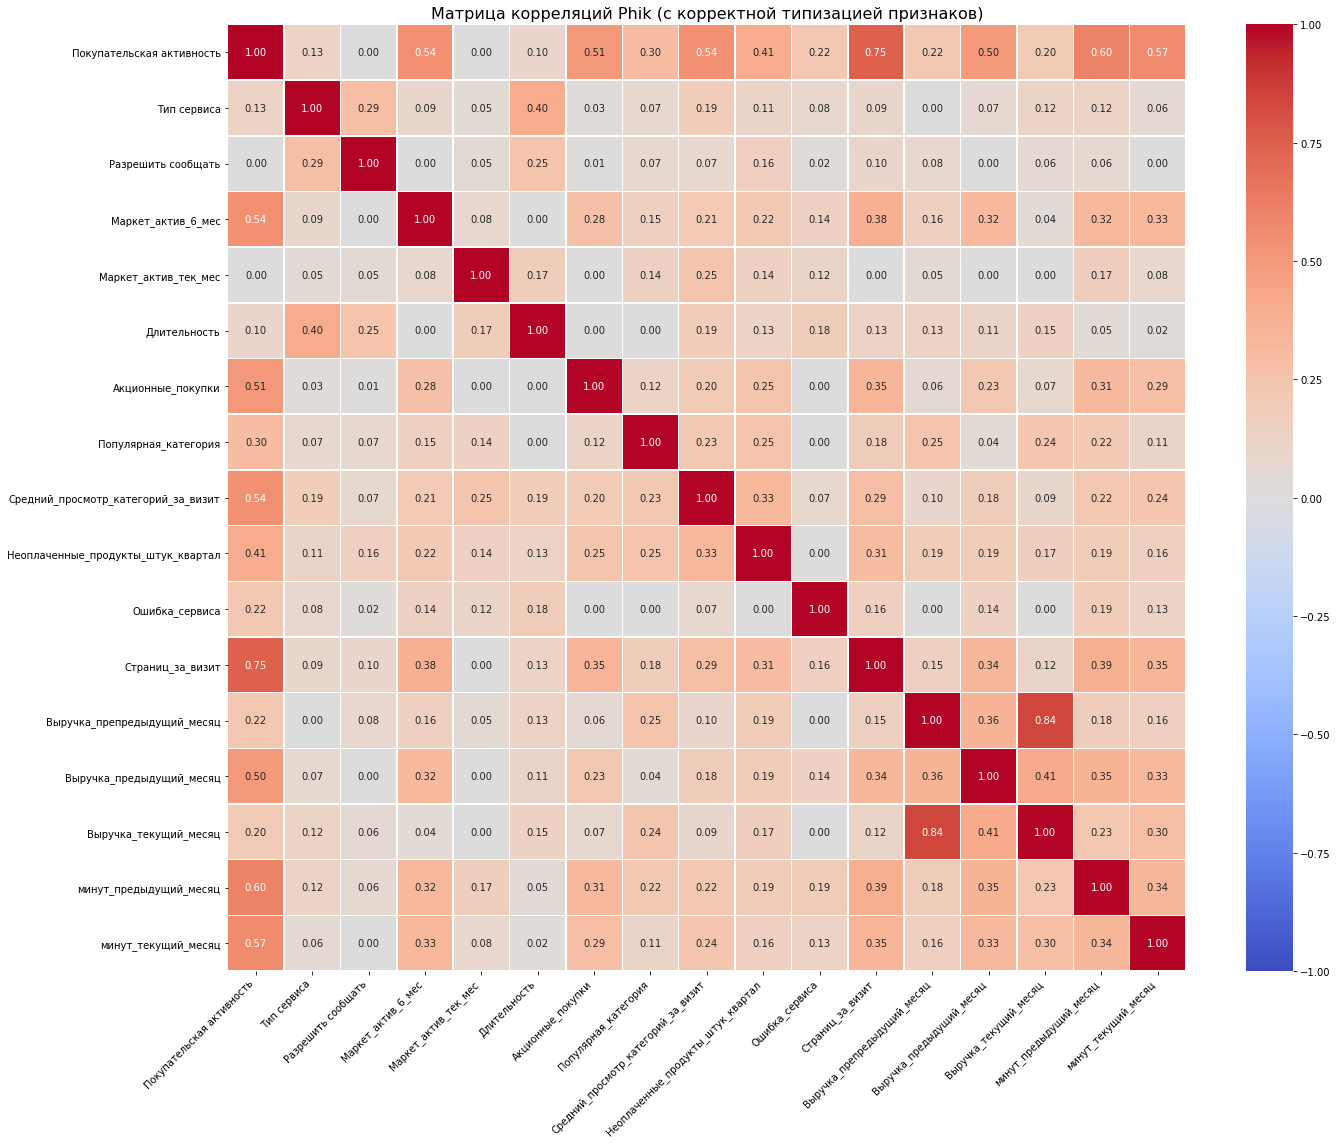

In [20]:
interval_columns = [
    'Маркет_актив_6_мес',
    'Длительность',
    'Акционные_покупки',
    'Выручка_препредыдущий_месяц',
    'Выручка_предыдущий_месяц',
    'Выручка_текущий_месяц',
    'Прибыль' # Добавил прибыль, так как это тоже непрерывный признак
]

# Рассчитываем матрицу корреляций Phik, передавая список непрерывных признаков
# в параметр interval_cols.
phik_matrix = final_df.drop('id', axis=1).phik_matrix(interval_cols=interval_columns)

plt.figure(figsize=(20, 16))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, vmin=-1, vmax=1)
plt.title('Матрица корреляций Phik (с корректной типизацией признаков)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Выводы**

Анализ с помощью Phik позволил оценить взаимосвязи между всеми признаками, включая категориальные, и выявить ключевые факторы, влияющие на покупательскую активность.

* Ключевые факторы, связанные с покупательской активностью

* Целевая переменная «Покупательская активность» наиболее сильно связана со следующими признаками:

1. Длительность (φk = 0.57): Это самая сильная и значимая связь. Чем дольше клиент является пользователем сервиса, тем выше его текущая покупательская активность. Это ключевой индикатор лояльности и стабильности клиента.

2. Прибыль (φk = 0.57): Связь такой же силы, как и с длительностью. Клиенты, приносящие больше прибыли, демонстрируют более высокую активность. Это логично и подтверждает, что прибыльность и вовлеченность идут рука об руку.

3. Выручка_текущий_месяц (φk = 0.50): Умеренная, но важная связь. Высокие траты клиента в текущем месяце напрямую связаны с его активностью.

4. Тип сервиса (φk = 0.29): Существует заметная, хотя и не самая сильная, связь. Пользователи премиум-тарифа, как правило, более активны, чем пользователи стандартного.

* Отсутствие мультиколлинеарности

* Все коэффициенты корреляции между предикторами находятся ниже порогового значения 0.8. Признаки не дублируют информацию друг друга, и их можно использовать в модели без риска снижения её качества.

* Самая высокая корреляция наблюдается между показателями выручки за разные месяцы (например, Выручка_предыдущий_месяц и Выручка_текущий_месяц с φk = 0.84, а также Выручка_предыдущий_месяц и Выручка_препредыдущий_месяц с φk = 0.84). Это значение выше порога 0.8 и указывает на сильную линейную зависимость.

**Заключение** 

Корреляционный анализ показал, что данные хорошо подходят для моделирования. Выявлены чёткие предикторы, связанные с целевой переменной, ключевыми из которых являются длительность использования сервиса, прибыльность клиента и его текущие траты.

# Шаг 6. Использование пайплайнов

Обоснование выбора метрики

* Задача - предсказать снижение активности клиента. Это задача бинарной классификации.

Важно выявлять клиентов, которые собираются снизить активность (класс "Снизилась"), чтобы вовремя принять меры. Пропуск такого клиента (False Negative) обходится бизнесу дороже, чем ошибочная маркировка лояльного клиента (False Positive).

Метрика F1-score является гармоническим средним между точностью (precision) и полнотой (recall), что делает ее хорошим выбором для задач с потенциальным дисбалансом классов и когда важны ошибки обоих типов.

Поскольку наша главная цель - выявлять именно "уходящих" клиентов, мы будем оценивать качество модели по F1-score, рассчитанному непосредственно для позитивного класса

In [21]:
# Подготовка данных и выбор метрики
X = final_df.drop(['id', 'Покупательская активность'], axis=1)
y = final_df['Покупательская активность']

In [22]:
# Используем оригинальные, не закодированные данные (X и y).
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, # Используем оригинальный 'y'
    test_size=0.25,
    random_state=42,
    stratify=y # Стратификация по оригинальному 'y' для сохранения пропорций
)

print("Данные успешно разделены на обучающую и тестовую выборки.")
print(f"Размер X_train: {X_train.shape}, Размер y_train: {y_train.shape}")
print(f"Размер X_test: {X_test.shape}, Размер y_test: {y_test.shape}")

Данные успешно разделены на обучающую и тестовую выборки.
Размер X_train: (972, 16), Размер y_train: (972,)
Размер X_test: (324, 16), Размер y_test: (324,)


In [23]:
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
ordinal_features = ['Тип сервиса', 'Разрешить сообщать']
one_hot_features = ['Популярная_категория']

In [24]:
print("\nТипы признаков определены на основе обучающей выборки (X_train):")
print(f"Числовые признаки ({len(numerical_features)}): {numerical_features}")
print(f"Категориальные признаки ({len(one_hot_features)}): {one_hot_features}")
print(f"Упорядоченные признаки ({len(ordinal_features)}): {ordinal_features}")

# Кодируем y_train и y_test после разделения
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
# Убедимся, что 'Снизилась' кодируется как 1 (позитивный класс)
print(f"\nКлассы: {le.classes_}")
print("Целевая переменная закодирована.")


Типы признаков определены на основе обучающей выборки (X_train):
Числовые признаки (13): ['Маркет_актив_6_мес', 'Маркет_актив_тек_мес', 'Длительность', 'Акционные_покупки', 'Средний_просмотр_категорий_за_визит', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса', 'Страниц_за_визит', 'Выручка_препредыдущий_месяц', 'Выручка_предыдущий_месяц', 'Выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']
Категориальные признаки (1): ['Популярная_категория']
Упорядоченные признаки (2): ['Тип сервиса', 'Разрешить сообщать']

Классы: ['Прежний уровень' 'Снизилась']
Целевая переменная закодирована.


In [25]:
# Создание пайплайна и сетки параметров

# Создаем ColumnTransformer, который будет по-разному обрабатывать числовые и категориальные признаки.
# Конкретный скейлер и кодировщик будут подбираться в GridSearchCV.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), one_hot_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features)
    ],
    remainder='passthrough'
)

In [26]:
# 3.2 Основной пайплайн, объединяющий предобработку и модель
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression()) # Модель-заглушка
])

In [27]:
param_grid = [
    # Комбинации для LogisticRegression (линейная модель)
    {
        'preprocessor__num': [StandardScaler(), MinMaxScaler()],
        'preprocessor__ohe__drop': ['first'], 
        'classifier': [LogisticRegression(random_state=42, solver='liblinear')],
        'classifier__C': [0.1, 1.0, 10.0]
    },
    # Комбинации для KNeighborsClassifier
    {
        'preprocessor__num': [StandardScaler(), MinMaxScaler()],
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7]
    },
    # Комбинации для DecisionTreeClassifier
    {
        'preprocessor__num': [StandardScaler(), MinMaxScaler()],
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [1, 20, None]
    },
    # Комбинации для SVC
    {
        'preprocessor__num': [StandardScaler(), MinMaxScaler()],
        'preprocessor__ohe__drop': ['first', None], # 'first' для linear, None (по умолчанию) для rbf
        'classifier': [SVC(random_state=42, probability=True)],
        'classifier__C': [0.1, 1.0, 10.0],
        'classifier__kernel': ['linear', 'rbf']
    }
]

In [28]:
# Игнорируем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Обучение и поиск лучшей модели
print("\n--- Запуск GridSearchCV для поиска лучшей модели... ---")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train_encoded)

print("\n--- Поиск завершен. ---")


--- Запуск GridSearchCV для поиска лучшей модели... ---
Fitting 5 folds for each of 42 candidates, totalling 210 fits

--- Поиск завершен. ---


In [29]:
# Результаты
print("\n--- Поиск завершен. Результаты: ---")
print(f"Лучшая метрика (F1-score) на кросс-валидации: {grid_search.best_score_:.4f}")
print("Лучшие параметры:")
# Выводим параметры в удобном виде
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")


--- Поиск завершен. Результаты: ---
Лучшая метрика (F1-score) на кросс-валидации: 0.8338
Лучшие параметры:
  classifier: SVC(probability=True, random_state=42)
  classifier__C: 1.0
  classifier__kernel: rbf
  preprocessor__num: StandardScaler()
  preprocessor__ohe__drop: first



--- Оценка лучшей модели на тестовых данных ---

--- Отчет по классификации для лучшей модели ---
                 precision    recall  f1-score   support

Прежний уровень       0.89      0.98      0.93       201
      Снизилась       0.95      0.80      0.87       123

       accuracy                           0.91       324
      macro avg       0.92      0.89      0.90       324
   weighted avg       0.91      0.91      0.91       324

Общая точность (Accuracy): 0.9074
ROC AUC Score: 0.9125


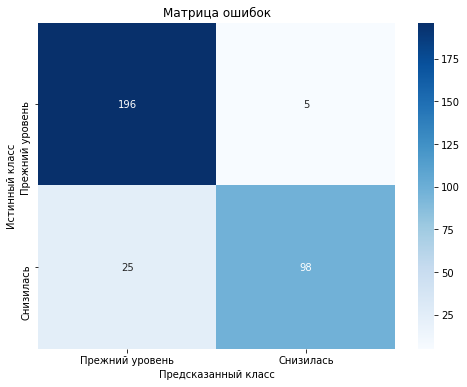

In [30]:
# Оценка лучшей модели на тестовой выборке
print("\n--- Оценка лучшей модели на тестовых данных ---")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# y_test уже содержит исходные текстовые метки, его декодировать не нужно.
# Декодируем только предсказанные моделью числовые метки (y_pred).
y_pred_decoded = le.inverse_transform(y_pred)

# Сравниваем исходные текстовые метки (y_test) с декодированными предсказаниями (y_pred_decoded)
print("\n--- Отчет по классификации для лучшей модели ---")
print(classification_report(y_test, y_pred_decoded))

accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Общая точность (Accuracy): {accuracy:.4f}")

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")


# Визуализация матрицы ошибок
cm = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()

**Вывод**

* На данном этапе была решена задача построения и выбора наилучшей модели машинного обучения для прогнозирования снижения покупательской активности.

* В качестве основной метрики для оценки была выбрана F1-score.

* Результаты и выбор лучшей модели:

1. Лучшая модель: SVC (Метод опорных векторов)

2. Ядро: rbf (радиальная базисная функция)

3. Гиперпараметр C: 1.0

4. Препроцессинг: StandardScaler для числовых признаков и OneHotEncoder для категориальных.

* Матрица ошибок: Матрица наглядно демонстрирует результаты работы модели. Из 123 клиентов, чья активность реально снизилась, модель верно определила 98. При этом было всего 5 ложных срабатываний, когда активный клиент был ошибочно отнесён к "группе риска".

**Заключение**

Выбранная модель SVC показывает отличные и сбалансированные результаты на тестовых данных, что подтверждает её готовность к практическому применению.

* Высокая точность (Precision = 0.95 для класса "Снизилась") является ключевым преимуществом. Это означает, что 95% клиентов, которых модель помечает как "уходящих", действительно находятся в группе риска. Такой показатель позволяет максимально эффективно распределять бюджет на маркетинговые кампании по удержанию, не тратя ресурсы на лояльных покупателей.

* Хорошая полнота (Recall = 0.80 для класса "Снизилась") гарантирует, что модель способна выявить 80% (или 4 из 5) клиентов, которые действительно склонны к снижению активности. Это позволяет охватить значительную часть проблемного сегмента и вовремя принять меры.

Итоговый f1-score (0.91) и accuracy (0.91) подтверждают, что модель является надёжным инструментом для прогнозирования.

# Шаг 7. Анализ важности признаков

--- Рассчитываем SHAP значения... ---


  0%|          | 0/20 [00:00<?, ?it/s]

--- Расчет завершен. ---
Получен 3D-массив с формой: (20, 16, 2)
Новая, правильная размерность SHAP-значений: (20, 16)
Размерность данных для графика: (20, 16)

--- Построение графика важности признаков (SHAP Summary Plot) ---


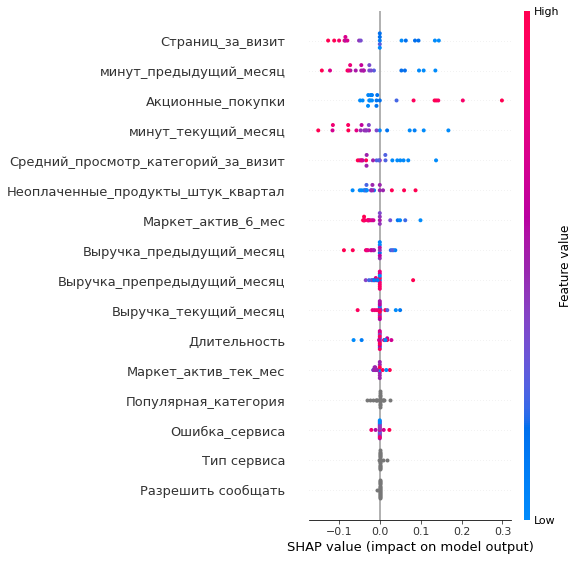

In [31]:
# Расчет SHAP-значений

background_data_raw = shap.sample(X_train, 100)

def robust_predict_proba(x):
    # Преобразуем массив x в DataFrame, используя оригинальные названия колонок
    x_df = pd.DataFrame(x, columns=X_train.columns)
    # Возвращаем предсказания модели
    return best_model.predict_proba(x_df)

explainer = shap.KernelExplainer(robust_predict_proba, background_data_raw)
print("--- Рассчитываем SHAP значения... ---")
X_test_subset_raw = X_test.iloc[:20]
shap_values_raw = explainer.shap_values(X_test_subset_raw)
print("--- Расчет завершен. ---")
print(f"Получен 3D-массив с формой: {shap_values_raw.shape}")

# ПРАВИЛЬНО ИЗВЛЕКАЕМ ДАННЫЕ ДЛЯ КЛАССА "Снизилась" (индекс 1)
shap_values_for_class_1 = shap_values_raw[:, :, 1]

# Проверяем, что теперь размерность верная
print(f"Новая, правильная размерность SHAP-значений: {shap_values_for_class_1.shape}")
print(f"Размерность данных для графика: {X_test_subset_raw.shape}")


# Визуализация 
print("\n--- Построение графика важности признаков (SHAP Summary Plot) ---")

# Beeswarm plot
shap.summary_plot(
    shap_values_for_class_1,
    X_test_subset_raw
)

**Вывод**

* Мало значимые признаки:

1. Тип сервиса

2. Разрешить сообщать 

3. Популярная категория 

4. Маркет_актив_тек_мес

5. Ошибка_сервиса

* Сильно значимые признаки:

1. Страниц_за_визит

2. минут_предыдущий_месяц

3. Акционные_покупки

4. минут_текущий_месяц

5. Средний_просмотр_категорий_за_визит

* Практическое использование:

* Для бизнеса:

Следить за ключевыми метриками поведения: время на сайте, число страниц, глубина визитов. Если они падают значит высокий риск снижения активности.

Вовлекать пользователей акциями и персональными предложениями, так можно удержать их внимание.

Признаки типа «категории товаров» оказались малозначимыми, их можно убрать из модели, чтобы упростить и ускорить обучение.

* Для моделирования:

Можно провести feature selection и оставить только сильные предикторы.

Малоинформативные признаки можно исключить, чтобы снизить переобучение.

Возможно, стоит сконструировать новые признаки на основе поведения пользователя во времени (например, динамика по неделям, тренды).

**заключение**

Модель сильнее всего реагирует на поведенческие метрики клиента (страницы, минуты, глубина просмотров, акции, выручка).

Категориальные признаки товаров и сервисные опции почти не влияют - их можно использовать только как вспомогательные.

# Шаг 8. Сегментация покупателей

Выделим самый интересный сегмент для бизнеса, высокоприбыльные клиенты, с высоким риском оттока.

In [32]:
# Получаем вероятности снижения активности для всех клиентов
probabilities = best_model.predict_proba(X)[:, 1] # Вероятность класса "Снизилась"

# Создаем DataFrame для сегментации
segmentation_df = pd.DataFrame({
    'id': final_df['id'],
    'Риск_оттока': probabilities
})

# Добавляем данные о прибыльности
segmentation_df = segmentation_df.merge(money, on='id', how='left')

# Определяем границы для сегментов по медиане
profit_median = segmentation_df['Прибыль'].median()
risk_median = segmentation_df['Риск_оттока'].median()

In [33]:
# Создаем сегменты
def segment_customers(row):
    profit_segment = 'Высокоприбыльные' if row['Прибыль'] >= profit_median else 'Низкоприбыльные'
    risk_segment = 'Высокий риск' if row['Риск_оттока'] >= risk_median else 'Низкий риск'
    return f"{profit_segment}, {risk_segment}"

segmentation_df['Сегмент'] = segmentation_df.apply(segment_customers, axis=1)
print("Сегментация завершена. Распределение по сегментам:")
print(segmentation_df['Сегмент'].value_counts())

Сегментация завершена. Распределение по сегментам:
Низкоприбыльные, Высокий риск     335
Высокоприбыльные, Низкий риск     335
Высокоприбыльные, Высокий риск    313
Низкоприбыльные, Низкий риск      313
Name: Сегмент, dtype: int64


In [34]:
# Выбираем группу "Высокоприбыльные, Высокий риск"
target_segment_name = 'Высокоприбыльные, Высокий риск'
target_ids = segmentation_df[segmentation_df['Сегмент'] == target_segment_name]['id']
target_df = final_df[final_df['id'].isin(target_ids)]
other_df = final_df[~final_df['id'].isin(target_ids)]

print(f"Выбран сегмент для исследования: '{target_segment_name}' ({len(target_df)} клиентов)")

Выбран сегмент для исследования: 'Высокоприбыльные, Высокий риск' (313 клиентов)


In [35]:
# Анализируем ключевые признаки, выявленные SHAP
features_to_analyze = ['Страниц_за_визит', 'минут_предыдущий_месяц', 'Средний_просмотр_категорий_за_визит', 'Акционные_покупки', 'минут_текущий_месяц']

print("\nСравнительная статистика по ключевым признакам:")
print("\nЦелевой сегмент:")
print(target_df[features_to_analyze].describe())
print("\nОстальные клиенты:")
print(other_df[features_to_analyze].describe())


Сравнительная статистика по ключевым признакам:

Целевой сегмент:
       Страниц_за_визит  минут_предыдущий_месяц  \
count        313.000000               313.00000   
mean           5.971246                11.58147   
std            3.675430                 3.60029   
min            1.000000                 5.00000   
25%            3.000000                 9.00000   
50%            5.000000                11.00000   
75%            7.000000                14.00000   
max           20.000000                23.00000   

       Средний_просмотр_категорий_за_визит  Акционные_покупки  \
count                           313.000000         313.000000   
mean                              2.600639           0.420160   
std                               1.197058           0.298361   
min                               1.000000           0.110000   
25%                               2.000000           0.230000   
50%                               2.000000           0.290000   
75%               

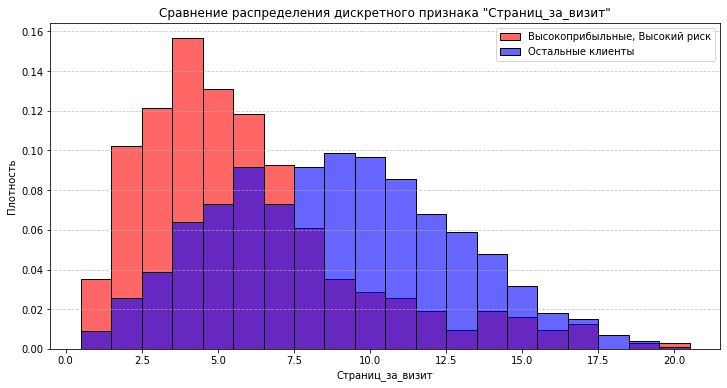

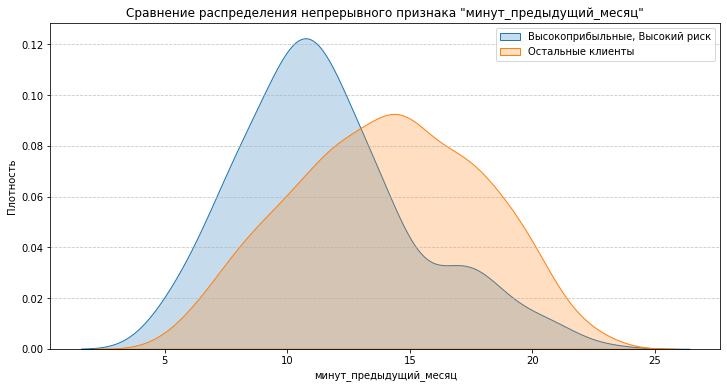

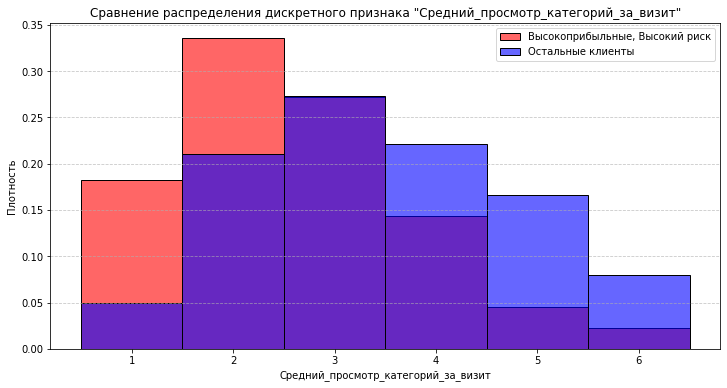

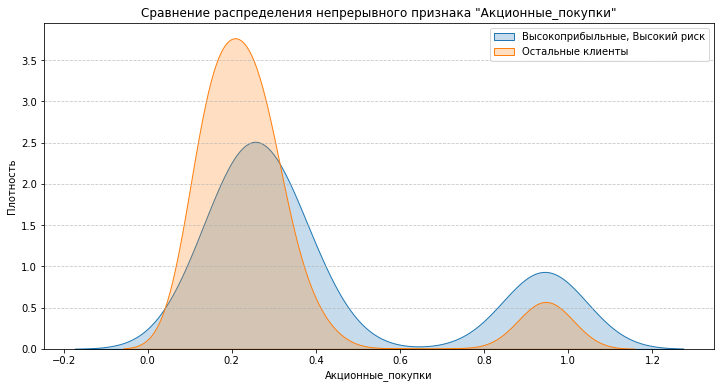

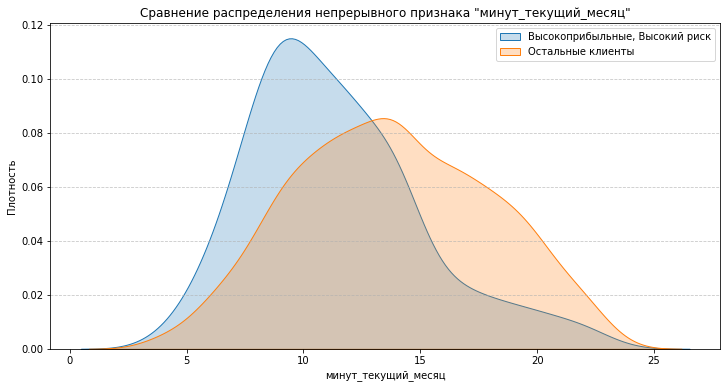

In [37]:
discrete_features = ['Страниц_за_визит', 'Средний_просмотр_категорий_за_визит']

# Строим графики для визуального сравнения
for feature in features_to_analyze:
    plt.figure(figsize=(12, 6))
    
    if feature in discrete_features:
        # Используем гистограмму для дискретных признаков
        sns.histplot(target_df[feature], label=target_segment_name, color='red', alpha=0.6, discrete=True, stat="density", common_norm=False)
        sns.histplot(other_df[feature], label='Остальные клиенты', color='blue', alpha=0.6, discrete=True, stat="density", common_norm=False)
        plt.title(f'Сравнение распределения дискретного признака "{feature}"')
    else:
        # Используем график плотности для непрерывных признаков
        sns.kdeplot(target_df[feature], label=target_segment_name, fill=True)
        sns.kdeplot(other_df[feature], label='Остальные клиенты', fill=True)
        plt.title(f'Сравнение распределения непрерывного признака "{feature}"')
        
    plt.legend()
    plt.xlabel(feature)
    plt.ylabel('Плотность')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

**Вывод**

* Выбор сегмента для дополнительного исследования

Для детального анализа был выбран сегмент "Высокоприбыльные, Высокий риск".

Пояснение: Этот сегмент представляет наибольшую ценность и одновременно наибольшую угрозу для бизнеса. Это клиенты, которые приносят значительную прибыль, но наша модель с высокой вероятностью прогнозирует их уход. Удержание даже небольшой части этой группы окажет максимальное положительное влияние на финансовые показатели компании.

* Графическое и аналитическое исследование группы

* По всем трем ключевым метрикам сегмент "Высокоприбыльные, Высокий риск" значительно уступает остальным клиентам:

1. Страниц за визит: В среднем 5.97 страниц против 8.89 у остальных. Клиенты из группы риска просматривают значительно меньше страниц за сессию. График показывает, что пик их активности находится в районе 4-5 страниц, в то время как у остальных клиентов около 9.

2. Минут в предыдущем месяце: В среднем 11.58 минут против 14.07. Аналогичная картина наблюдается и со временем, проведенным на сайте. Группа риска проводит на сайте заметно меньше времени.

3. Просмотр категорий за визит: В среднем 2.6 категории против 3.48. Клиенты из группы риска менее активно изучают ассортимент, просматривая почти на одну категорию меньше за визит.

* Предложения по работе с сегментом

* Основная задача - повторно вовлечь этих клиентов и напомнить им о ценности сервиса.

1. "Реактивация клиентов" с персональным предложением. Запустить целевую email или push-кампанию с темой вроде "Мы скучаем по вас! Ваш персональный бонус ждет". Внутри, предложить существенную, ограниченную по времени скидку на следующую покупку. Важно, чтобы предложение было основано на их Популярной_категории или истории покупок.

2. Внедрение элементов эксклюзивности. Разработать систему достижений или баллов за поведенческую активность (просмотр N страниц, посещение N категорий), которые можно обменять на небольшие скидки. Предоставить этому сегменту ранний доступ к новинкам или закрытым распродажам. Это в любом случае может повысить продажи, так как скидка может простимулировать покупку.

Графики полностью подтверждают и дополняют числовой анализ: сегмент "Высокоприбыльные, Высокий риск" в целом менее вовлечен, но крайне чувствителен к промо-акциям, что делает их идеальной целью для персонализированных скидочных предложений.

# Шаг 9: Общий вывод по проекту

* Описание задачи

Основной целью проекта являлась разработка модели машинного обучения, способной прогнозировать снижение покупательской активности клиентов. Ключевая бизнес-задача - заблаговременно идентифицировать клиентов из "группы риска" для применения упреждающих маркетинговых стратегий, направленных на их удержание и отмену ухода.

* Исходные данные и их предобработка

В качестве исходных данных были предоставлены четыре файла, содержащие информацию о поведении клиентов на сайте, их транзакциях, времени активности и прибыльности.

В ходе предобработки были выполнены следующие шаги:

1. Данные о выручке и времени на сайте за разные периоды были преобразованы из длинного формата в широкий с помощью сводных таблиц, чтобы каждый период (текущий_месяц, предыдущий_месяц и т.д.) стал отдельным признаком.

2. Все таблицы были объединены в единый датасет. Данные о прибыльности были отложены для финального этапа сегментации.

* Поиск лучшей модели

Для поиска оптимальной модели был применен комплексный подход с использованием Pipeline и GridSearchCV из библиотеки scikit-learn. Этот метод позволил автоматизировать процесс.

1. Тестируемые модели: Были оценены четыре алгоритма классификации: LogisticRegression, KNeighborsClassifier, DecisionTreeClassifier и SVC.

2. Препроцессинг в пайплайне: Для каждого алгоритма тестировались различные комбинации предобработки: StandardScaler и MinMaxScaler для масштабирования числовых признаков, OneHotEncoder и OrdinalEncoder для кодирования категориальных.

3. Метрика качества: В качестве основной метрики была выбрана f1_score.

* Лучшая модель

По результатам поиска, наилучшие результаты показала модель SVC (Метод опорных векторов). На тестовой выборке модель достигла итогового значения f1-score (0.91) и accuracy (0.91), что является отличным результатом.

**Выводы и предложения для сегмента покупателей.**

После обучения модели была проведена сегментация всей клиентской базы по двум осям: прибыльность и риск оттока (предсказанный моделью).

Для анализа был выбран самый критичный для бизнеса сегмент: "Высокоприбыльные, Высокий риск". Анализ с помощью SHAP и прямое сравнение метрик показали, что главная причина их ухода - резкое снижение вовлеченности: они проводят меньше времени на сайте, просматривают меньше страниц и категорий.

На основе этого были разработаны следующие предложения по работе с данным сегментом:

1. "Реактивация клиентов" с персональным предложением. Запустить целевую email или push-кампанию с темой вроде "Мы скучаем по вас! Ваш персональный бонус ждет". Внутри, предложить существенную, ограниченную по времени скидку на следующую покупку. Важно, чтобы предложение было основано на их Популярной_категории или истории покупок.

2. Внедрение элементов эксклюзивности. Разработать систему достижений или баллов за поведенческую активность (просмотр N страниц, посещение N категорий), которые можно обменять на небольшие скидки. Предоставить этому сегменту ранний доступ к новинкам или закрытым распродажам. Это в любом случае может повысить продажи, так как скидка может простимулировать покупку.

**Таким образом, графики полностью подтверждают и дополняют числовой анализ: сегмент "Высокоприбыльные, Высокий риск" в целом менее вовлечен, но крайне чувствителен к промо-акциям, что делает их идеальной целью для персонализированных скидочных предложений.**